# Step 5.3 - Visualization

**Goal:** Colour-code the t-SNE projections from Step 4.1 with cluster labels and official Hauptgruppen to visually assess clustering quality and correspondence with the official SGBS classification.

**Why here and not in Step 4?**  
t-SNE projections without labels show the geometric structure of the data but are hard to interpret. Cluster labels (from Steps 5.1 and 5.2) make the plots meaningful: we can see which regions are captured by which cluster, where noise falls, and how well algorithmic groupings align with the official classification.

**Six views per feature representation:**
1. K-Means k=9 labels
2. DBSCAN labels (noise in grey)
3. Official Hauptgruppen (1-9)

Applied to both TF-IDF and Word2Vec t-SNE projections.

## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

TSNE_TFIDF_PATH      = "../data/processed/tsne_tfidf_2d.npy"
TSNE_W2V_PATH        = "../data/processed/tsne_w2v_2d.npy"
KMEANS_RESULTS_PATH      = "../data/processed/kmeans_results.csv"
DBSCAN_TFIDF_PATH    = "../data/processed/dbscan_labels_tfidf.npy"
DBSCAN_W2V_PATH      = "../data/processed/dbscan_labels_w2v.npy"
KM_TFIDF_9_PATH      = "../data/processed/kmeans_labels_tfidf_k9.npy"
KM_W2V_9_PATH        = "../data/processed/kmeans_labels_w2v_k9.npy"
OUTLIER_FLAGS_PATH   = "../data/processed/outlier_flags.csv"
CLEAN_DATA_PATH      = "../data/processed/sgbs_clean.csv"

os.makedirs("../report/figures", exist_ok=True)

# Load t-SNE projections
X_tfidf_tsne = np.load(TSNE_TFIDF_PATH)   # (730, 2)
X_w2v_tsne   = np.load(TSNE_W2V_PATH)     # (730, 2)

# Load cluster labels directly from .npy files
results = pd.read_csv(KMEANS_RESULTS_PATH)
results["cluster_dbscan_tfidf"] = np.load(DBSCAN_TFIDF_PATH)
results["cluster_dbscan_w2v"]   = np.load(DBSCAN_W2V_PATH)
results["cluster_tfidf_9"]       = np.load(KM_TFIDF_9_PATH)
results["cluster_w2v_9"]         = np.load(KM_W2V_9_PATH)

df_full = pd.read_csv(CLEAN_DATA_PATH)
flags   = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE = flags.index[flags['exclude'] == True].tolist()
df = df_full.drop(index=EXCLUDE).reset_index(drop=True)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)

assert len(X_tfidf_tsne) == len(results) == len(df), \
    f"Row count mismatch: tsne={len(X_tfidf_tsne)}, results={len(results)}, df={len(df)}"

print(f"t-SNE TF-IDF:  {X_tfidf_tsne.shape}")
print(f"t-SNE W2V:     {X_w2v_tsne.shape}")
print(f"Cluster cols:  {[c for c in results.columns if 'cluster' in c]}")

t-SNE TF-IDF:  (730, 2)
t-SNE W2V:     (730, 2)
Cluster cols:  ['cluster_tfidf', 'cluster_w2v', 'cluster_tfidf_9', 'cluster_w2v_9', 'cluster_dbscan_tfidf', 'cluster_dbscan_w2v']


## 2. Colour Palettes

In [6]:
# 9 distinct colours for Hauptgruppen and K-Means k=9
HG_COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4'
]

def make_legend(labels_unique, colors, label_map=None):
    patches = []
    for lbl, col in zip(labels_unique, colors):
        name = label_map.get(str(lbl), str(lbl)) if label_map else str(lbl)
        patches.append(mpatches.Patch(color=col, label=name))
    return patches

print("Colour palettes ready.")

Colour palettes ready.


## 3. Overview: 2x3 Grid — TF-IDF t-SNE

Three views of the same TF-IDF t-SNE projection:
- Left: K-Means k=9
- Centre: DBSCAN (noise in grey)
- Right: Official Hauptgruppen

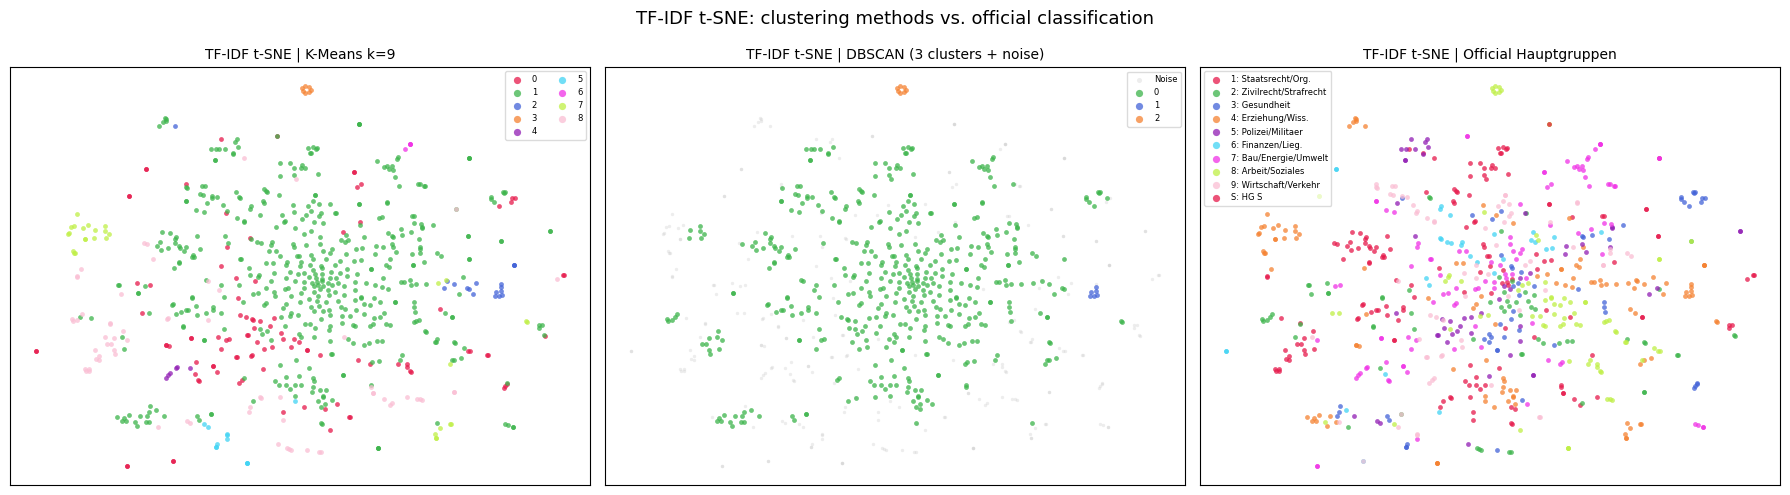

Figure saved.


In [7]:
def scatter_tsne(ax, X2d, labels, colors, title, label_map=None, noise_label=-1):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask  = np.array(labels) == lbl
        color = '#cccccc' if lbl == noise_label else colors[i % len(colors)]
        alpha = 0.35 if lbl == noise_label else 0.75
        size  = 6 if lbl == noise_label else 12
        name  = 'Noise' if lbl == noise_label else (
            label_map.get(str(lbl), str(lbl)) if label_map else str(lbl)
        )
        ax.scatter(X2d[mask, 0], X2d[mask, 1], s=size, alpha=alpha,
                   color=color, label=name, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    leg = ax.legend(fontsize=6, markerscale=1.5, loc='best',
                    framealpha=0.7, ncol=2 if len(unique) > 6 else 1)
    return leg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means k=9
scatter_tsne(axes[0], X_tfidf_tsne,
             results['cluster_tfidf_9'].tolist(),
             HG_COLORS,
             f"TF-IDF t-SNE | K-Means k=9")

# DBSCAN
scatter_tsne(axes[1], X_tfidf_tsne,
             results['cluster_dbscan_tfidf'].tolist(),
             HG_COLORS,
             f"TF-IDF t-SNE | DBSCAN (3 clusters + noise)",
             noise_label=-1)

# Official Hauptgruppen
hg_labels = df['hauptgruppe'].tolist()
hg_unique = sorted(set(hg_labels))
hg_color_map = {k: HG_COLORS[i % len(HG_COLORS)] for i, k in enumerate(hg_unique)}
for i, hg in enumerate(hg_unique):
    mask = np.array(hg_labels) == hg
    label = HAUPTGRUPPEN.get(hg, f'HG {hg}')
    axes[2].scatter(X_tfidf_tsne[mask, 0], X_tfidf_tsne[mask, 1],
                    s=12, alpha=0.75, color=HG_COLORS[i % len(HG_COLORS)],
                    label=f"{hg}: {label}", linewidths=0)
axes[2].set_title("TF-IDF t-SNE | Official Hauptgruppen", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
axes[2].legend(fontsize=6, markerscale=1.5, loc='best', framealpha=0.7)

plt.suptitle("TF-IDF t-SNE: clustering methods vs. official classification", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_3_tsne_tfidf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 4. Overview: 2x3 Grid — Word2Vec t-SNE

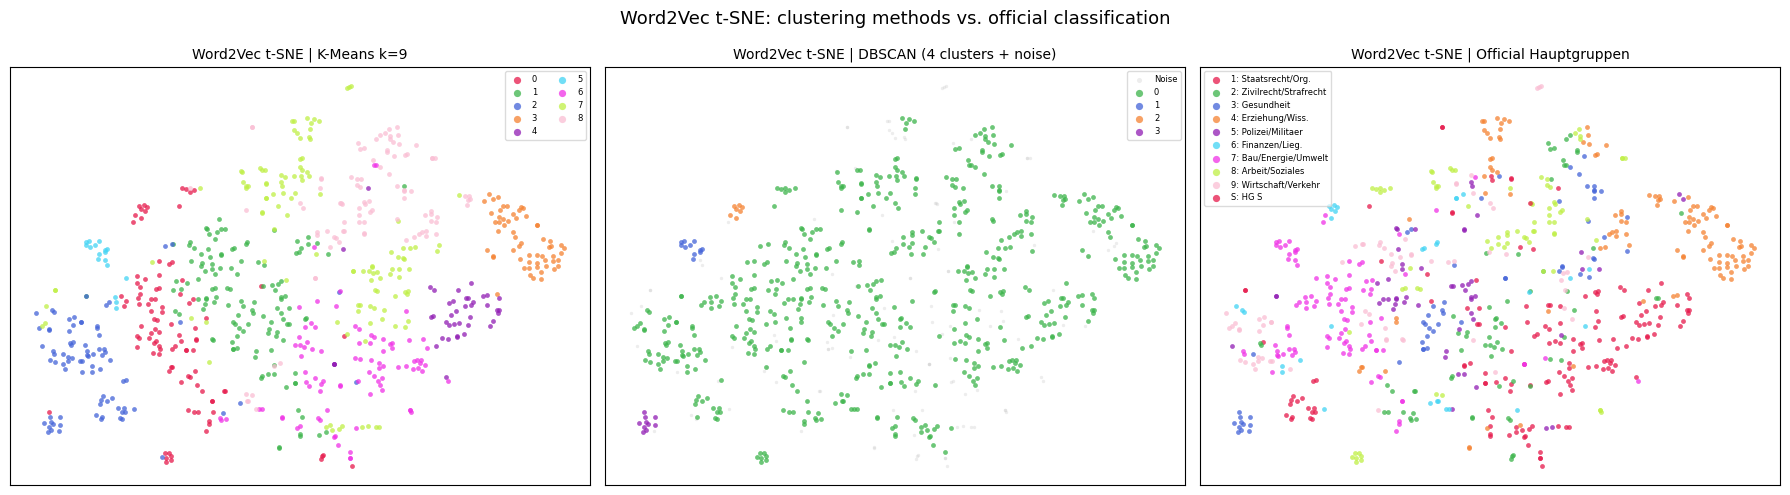

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means k=9
scatter_tsne(axes[0], X_w2v_tsne,
             results['cluster_w2v_9'].tolist(),
             HG_COLORS,
             "Word2Vec t-SNE | K-Means k=9")

# DBSCAN
scatter_tsne(axes[1], X_w2v_tsne,
             results['cluster_dbscan_w2v'].tolist(),
             HG_COLORS,
             "Word2Vec t-SNE | DBSCAN (4 clusters + noise)",
             noise_label=-1)

# Official Hauptgruppen
for i, hg in enumerate(hg_unique):
    mask = np.array(hg_labels) == hg
    label = HAUPTGRUPPEN.get(hg, f'HG {hg}')
    axes[2].scatter(X_w2v_tsne[mask, 0], X_w2v_tsne[mask, 1],
                    s=12, alpha=0.75, color=HG_COLORS[i % len(HG_COLORS)],
                    label=f"{hg}: {label}", linewidths=0)
axes[2].set_title("Word2Vec t-SNE | Official Hauptgruppen", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
axes[2].legend(fontsize=6, markerscale=1.5, loc='best', framealpha=0.7)

plt.suptitle("Word2Vec t-SNE: clustering methods vs. official classification", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_3_tsne_w2v.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 5. Combined Report Figure

A single 2x3 figure combining both representations for the report: rows = TF-IDF / Word2Vec, columns = K-Means / DBSCAN / Hauptgruppen.

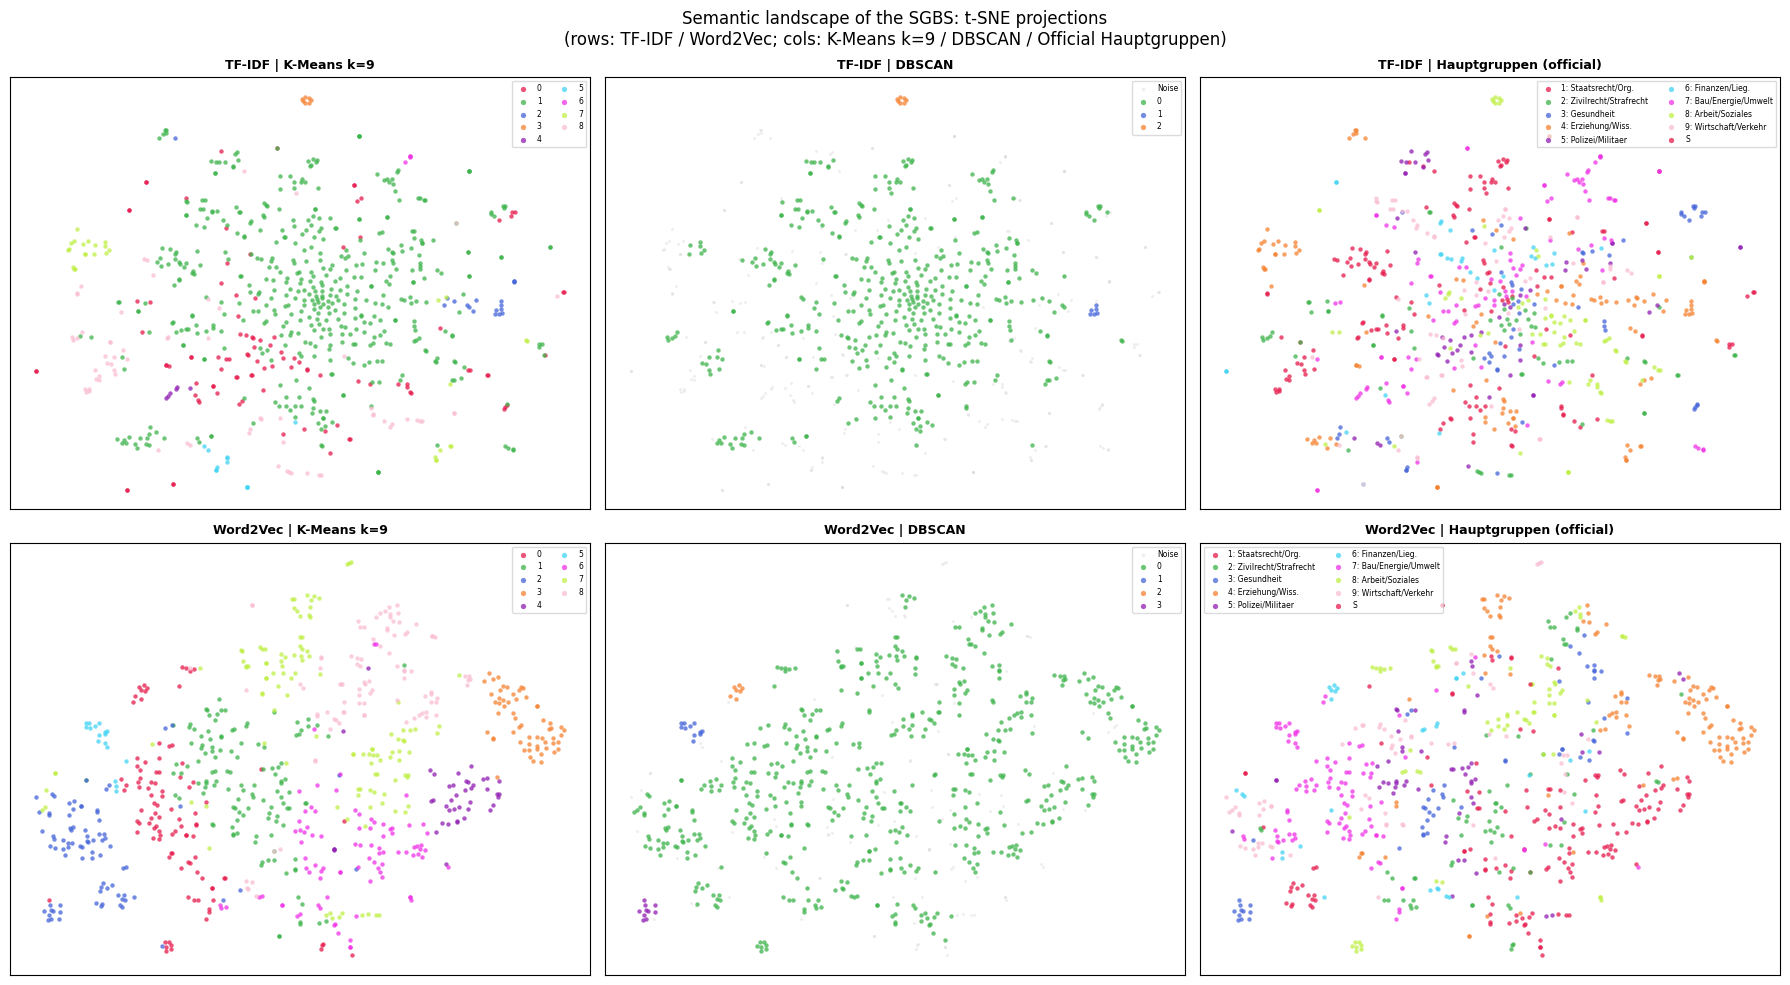

Report figure saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    # (row, col, X2d, labels, title, noise_label)
    (0, 0, X_tfidf_tsne, results['cluster_tfidf_9'].tolist(),    "TF-IDF | K-Means k=9",           None),
    (0, 1, X_tfidf_tsne, results['cluster_dbscan_tfidf'].tolist(),"TF-IDF | DBSCAN",               -1),
    (0, 2, X_tfidf_tsne, hg_labels,                               "TF-IDF | Hauptgruppen (official)", None),
    (1, 0, X_w2v_tsne,   results['cluster_w2v_9'].tolist(),       "Word2Vec | K-Means k=9",         None),
    (1, 1, X_w2v_tsne,   results['cluster_dbscan_w2v'].tolist(),  "Word2Vec | DBSCAN",              -1),
    (1, 2, X_w2v_tsne,   hg_labels,                               "Word2Vec | Hauptgruppen (official)", None),
]

for row, col, X2d, labels, title, noise_label in configs:
    ax = axes[row, col]
    # Use Hauptgruppen label map for col 2
    lmap = HAUPTGRUPPEN if col == 2 else None
    nl   = noise_label if noise_label is not None else -999
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask  = np.array(labels) == lbl
        color = '#cccccc' if lbl == nl else HG_COLORS[i % len(HG_COLORS)]
        alpha = 0.3 if lbl == nl else 0.75
        size  = 5 if lbl == nl else 10
        name  = ('Noise' if lbl == nl else
                 (f"{lbl}: {lmap[str(lbl)]}" if lmap and str(lbl) in lmap else str(lbl)))
        ax.scatter(X2d[mask, 0], X2d[mask, 1], s=size, alpha=alpha,
                   color=color, label=name, linewidths=0)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=5.5, markerscale=1.2, loc='best',
              framealpha=0.7, ncol=2 if len(unique) > 6 else 1)

plt.suptitle("Semantic landscape of the SGBS: t-SNE projections\n"
             "(rows: TF-IDF / Word2Vec; cols: K-Means k=9 / DBSCAN / Official Hauptgruppen)",
             fontsize=12)
plt.tight_layout()
plt.savefig("../report/figures/05_3_tsne_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Report figure saved.")

## 6. Noise Distribution across Hauptgruppen (DBSCAN TF-IDF)

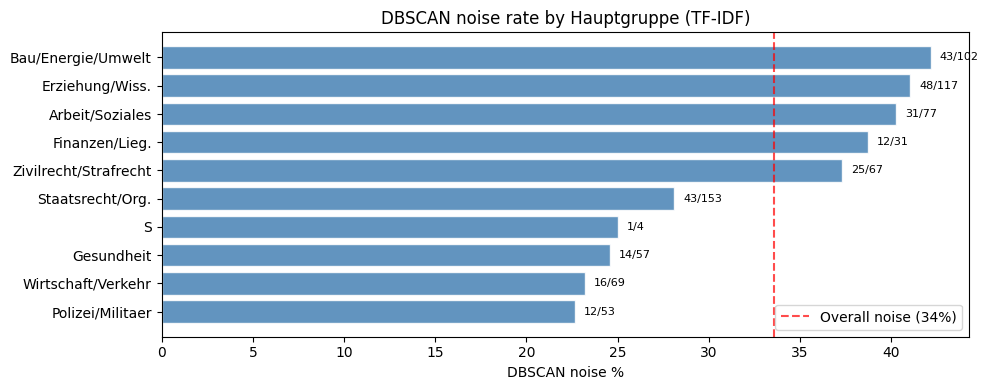

                             label  sum  count  noise_pct
hauptgruppe                                              
5                 Polizei/Militaer   12     53  22.641509
9               Wirtschaft/Verkehr   16     69  23.188406
3                       Gesundheit   14     57  24.561404
S                                S    1      4  25.000000
1                 Staatsrecht/Org.   43    153  28.104575
2            Zivilrecht/Strafrecht   25     67  37.313433
6                   Finanzen/Lieg.   12     31  38.709677
8                  Arbeit/Soziales   31     77  40.259740
4                  Erziehung/Wiss.   48    117  41.025641
7               Bau/Energie/Umwelt   43    102  42.156863


In [10]:
df['dbscan_tfidf'] = results['cluster_dbscan_tfidf'].values
df['is_noise_tfidf'] = df['dbscan_tfidf'] == -1

noise_by_hg = df.groupby('hauptgruppe')['is_noise_tfidf'].agg(['sum', 'count'])
noise_by_hg['noise_pct'] = noise_by_hg['sum'] / noise_by_hg['count'] * 100
noise_by_hg['label'] = noise_by_hg.index.map(lambda x: HAUPTGRUPPEN.get(x, x))
noise_by_hg = noise_by_hg.sort_values('noise_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(noise_by_hg['label'], noise_by_hg['noise_pct'],
               color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['is_noise_tfidf'].mean() * 100, color='red',
           linestyle='--', alpha=0.7, label=f"Overall noise ({df['is_noise_tfidf'].mean()*100:.0f}%)")
for bar, (_, row) in zip(bars, noise_by_hg.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['sum']:.0f}/{row['count']:.0f}",
            va='center', fontsize=8)
ax.set_xlabel("DBSCAN noise %")
ax.set_title("DBSCAN noise rate by Hauptgruppe (TF-IDF)")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/05_3_dbscan_noise_by_hg.png", dpi=150)
plt.show()

print(noise_by_hg[['label', 'sum', 'count', 'noise_pct']].to_string())

## 7. Summary

**What we produced:**
- `05_3_tsne_tfidf.png` — TF-IDF t-SNE, three colouring schemes
- `05_3_tsne_w2v.png` — Word2Vec t-SNE, three colouring schemes
- `05_3_tsne_overview.png` — Combined 2x3 report figure
- `05_3_dbscan_noise_by_hg.png` — DBSCAN noise rate per Hauptgruppe

**Next step:** `06_iteration.ipynb` — synthesis, cross-method comparison, conclusions, and report preparation.